# Parte 1. Concatenar CSVs

In [59]:
import os
import pandas as pd

base_dir = "outputs/por_chico"

dfs = []

for root, dirs, files in os.walk(base_dir):
    for fname in files:
        if not fname.lower().endswith(".csv"):
            continue
        if not fname.startswith("df_results_"):
            continue

        filepath = os.path.join(root, fname)

        name_no_ext = os.path.splitext(fname)[0]
        name_core = name_no_ext.replace("df_results_", "", 1)

        partes = name_core.split("-")

        nombre = partes[0] if len(partes) > 0 else ""
        numero_audio = partes[1] if len(partes) > 1 else ""
        nivel_socio = partes[2] if len(partes) > 2 else ""

        df = pd.read_csv(filepath)

        df["nombre"] = nombre
        df["numero_audio"] = numero_audio
        df["nivel_socio"] = nivel_socio
        df["archivo_origen"] = fname
        df["carpeta_origen"] = os.path.basename(root)

        cols_first = ["nombre", "numero_audio", "nivel_socio", "archivo_origen", "carpeta_origen"]
        other_cols = [c for c in df.columns if c not in cols_first]
        df = df[cols_first + other_cols]

        dfs.append(df)

df_resultados_concat = pd.concat(dfs, ignore_index=True)

print("Filas:", len(df_resultados_concat))
print("Chicos únicos:", df_resultados_concat["nombre"].nunique())

Filas: 10176004
Chicos únicos: 24


# Parte 2. Guardar concatenado

In [60]:
import math

output_dir = "outputs/final_concats"
os.makedirs(output_dir, exist_ok=True)

max_size_bytes = 100 * 1024 * 1024  

# --- Estimar tamaño por fila usando una muestra ---
sample_n = min(10000, len(df_resultados_concat))

if sample_n == 0:
    print("DataFrame vacío.")
else:
    sample_df = df_resultados_concat.iloc[:sample_n]
    temp_path = os.path.join(output_dir, "_tmp_sample.csv")
    sample_df.to_csv(temp_path, index=False)
    sample_size = os.path.getsize(temp_path)
    os.remove(temp_path)

    bytes_per_row = sample_size / sample_n
    rows_per_file = max(1, int(max_size_bytes / bytes_per_row))

    n_parts = math.ceil(len(df_resultados_concat) / rows_per_file)

    print(f"Filas por archivo aprox: {rows_per_file}")
    print(f"Cantidad de archivos: {n_parts}")

    # --- Escribir por bloques (rápido) ---
    for i in range(n_parts):
        start = i * rows_per_file
        end = min((i + 1) * rows_per_file, len(df_resultados_concat))

        chunk = df_resultados_concat.iloc[start:end]

        output_csv = os.path.join(output_dir, f"df_resultados_concat_part_{i+1}.csv")
        chunk.to_csv(output_csv, index=False)

print("Archivos divididos correctamente.")

Filas por archivo aprox: 1397750
Cantidad de archivos: 8
Archivos divididos correctamente.


# Parte 3. Crear SOLO SIL (sin ELE)

In [61]:
import numpy as np

df = df_resultados_concat.copy()

cols_elan = ["Elan_KCHI", "Elan_OCH", "Elan_FEM", "Elan_MAL"]
cols_diar = ["Diar_KCHI", "Diar_OCH", "Diar_FEM", "Diar_MAL", "Diar_SPEECH"]

# SIL en Elan
df["Elan_SIL"] = (df[cols_elan].eq(0).all(axis=1)).astype(int)

# SIL en Diar
df["Diar_SIL"] = 1 - df["Diar_SPEECH"]

# Parte 4. Armar multilabel SIN ELE

In [62]:
labels = ["KCHI", "OCH", "FEM", "MAL", "SIL"]

y_true_multi = df[
    ["Elan_KCHI", "Elan_OCH", "Elan_FEM", "Elan_MAL", "Elan_SIL"]
].values

y_pred_multi = df[
    ["Diar_KCHI", "Diar_OCH", "Diar_FEM", "Diar_MAL", "Diar_SIL"]
].values

# Parte 5. Multilabel confusion + report

In [63]:
from sklearn.metrics import multilabel_confusion_matrix, classification_report

conf_matrix = multilabel_confusion_matrix(y_true_multi, y_pred_multi)

for i, label in enumerate(labels):
    print(f"\nMatriz para {label}:")
    print(conf_matrix[i])

print("\nReporte multilabel:")
print(classification_report(
    y_true_multi,
    y_pred_multi,
    target_names=labels,
    zero_division=0
))


Matriz para KCHI:
[[8547848  643590]
 [ 368656  615910]]

Matriz para OCH:
[[8785976  669228]
 [ 458436  262364]]

Matriz para FEM:
[[7425552 1168514]
 [ 661852  920086]]

Matriz para MAL:
[[9224420  364646]
 [ 353070  233868]]

Matriz para SIL:
[[2690396  779614]
 [2255920 4450074]]

Reporte multilabel:
              precision    recall  f1-score   support

        KCHI       0.49      0.63      0.55    984566
         OCH       0.28      0.36      0.32    720800
         FEM       0.44      0.58      0.50   1581938
         MAL       0.39      0.40      0.39    586938
         SIL       0.85      0.66      0.75   6705994

   micro avg       0.64      0.61      0.63  10580236
   macro avg       0.49      0.53      0.50  10580236
weighted avg       0.69      0.61      0.64  10580236
 samples avg       0.61      0.62      0.61  10580236



# Parte 6. Multilabel → Single label

In [64]:
def multilabel_to_singlelabel(y_multilabel):
    single_labels = []
    for row in y_multilabel:
        indices = np.where(row == 1)[0]
        if len(indices) == 0:
            single_labels.append(-1)
        else:
            single_labels.append(indices[0])
    return np.array(single_labels)

y_true = multilabel_to_singlelabel(y_true_multi)
y_pred = multilabel_to_singlelabel(y_pred_multi)

valid_indices = y_true != -1
y_true = y_true[valid_indices]
y_pred = y_pred[valid_indices]

# Parte 7. Matriz de confusión global 

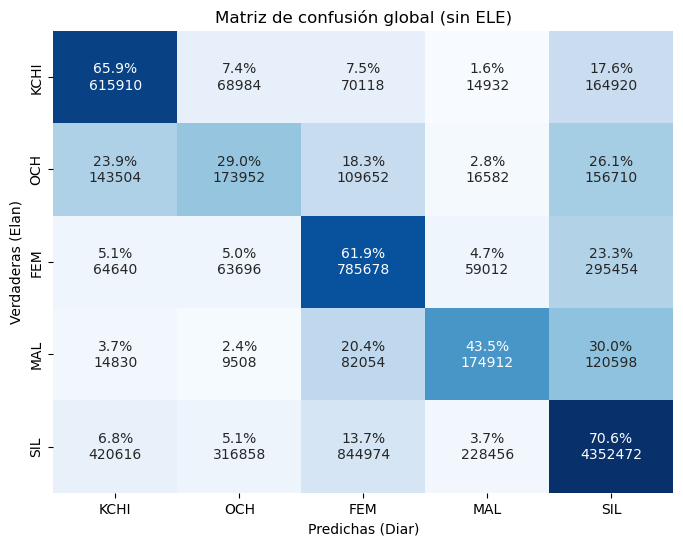

In [65]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

labels_idx = range(len(labels))

cm_counts = confusion_matrix(y_true, y_pred, labels=labels_idx)
cm_norm = confusion_matrix(y_true, y_pred, labels=labels_idx, normalize="true")

cm_counts_df = pd.DataFrame(cm_counts, index=labels, columns=labels)
cm_norm_df = pd.DataFrame(cm_norm, index=labels, columns=labels)

annot = (cm_norm_df * 100).round(1).astype(str) + "%" + "\n" + cm_counts_df.astype(int).astype(str)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_norm_df,
    annot=annot,
    fmt="",
    cmap="Blues",
    cbar=False
)

plt.title("Matriz de confusión global (sin ELE)")
plt.ylabel("Verdaderas (Elan)")
plt.xlabel("Predichas (Diar)")

plt.savefig(
    "outputs/final_concats/matriz_confusion_global_sin_ELE.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# Parte 8. Métricas por clase

In [66]:
from sklearn.metrics import classification_report

valid_indices = (y_true != -1) & (y_pred != -1)

y_true_f = y_true[valid_indices]
y_pred_f = y_pred[valid_indices]

report_dict = classification_report(
    y_true_f,
    y_pred_f,
    labels=list(range(len(labels))),
    target_names=labels,
    output_dict=True,
    zero_division=0
)

df_metrics = (
    pd.DataFrame(report_dict)
    .T
    .reset_index()
    .rename(columns={
        "index": "Tipo",
        "precision": "Precisión",
        "recall": "Recall",
        "f1-score": "F1-score",
        "support": "Support"
    })
)

df_metrics = df_metrics[df_metrics["Tipo"].isin(labels)].copy()

print(df_metrics)

   Tipo  Precisión    Recall  F1-score    Support
0  KCHI   0.489012  0.658823  0.561356   934864.0
1   OCH   0.274807  0.289727  0.282070   600400.0
2   FEM   0.415159  0.619385  0.497114  1268480.0
3   MAL   0.354149  0.435211  0.390517   401902.0
4   SIL   0.855077  0.706183  0.773530  6163376.0


# Parte 9. Gráficos

C:\Users\pablo\AppData\Local\Temp\ipykernel_4764\4115792610.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


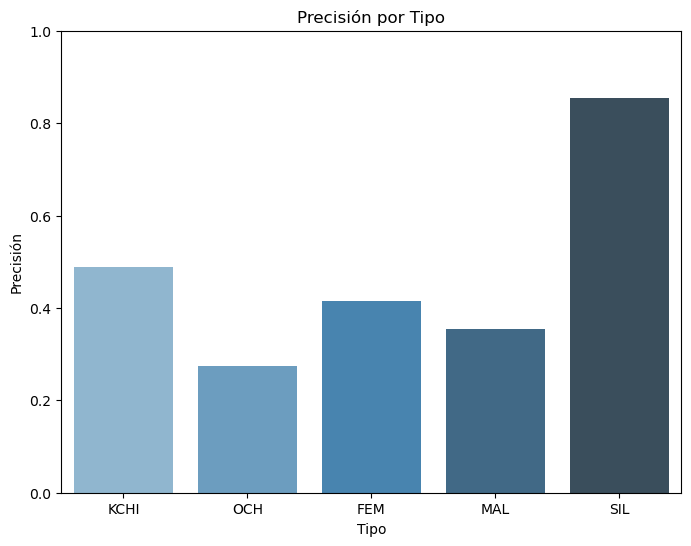

C:\Users\pablo\AppData\Local\Temp\ipykernel_4764\4115792610.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


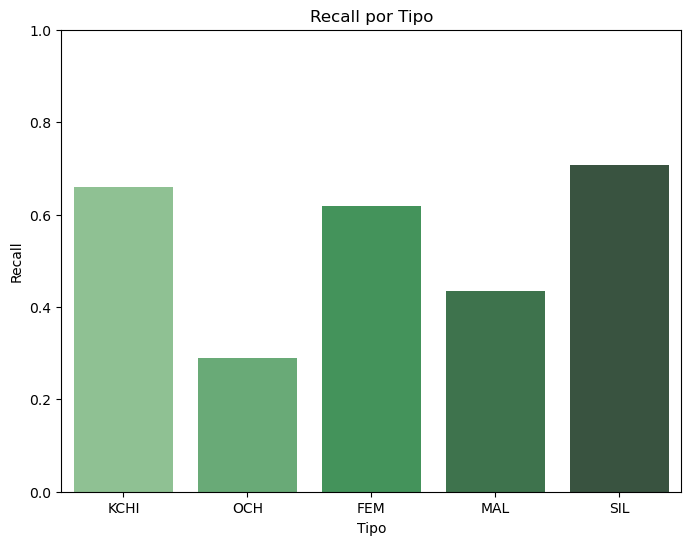

C:\Users\pablo\AppData\Local\Temp\ipykernel_4764\4115792610.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


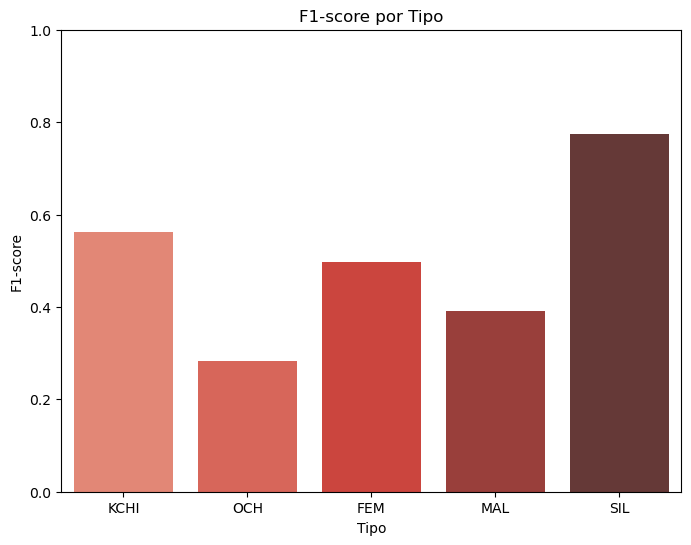

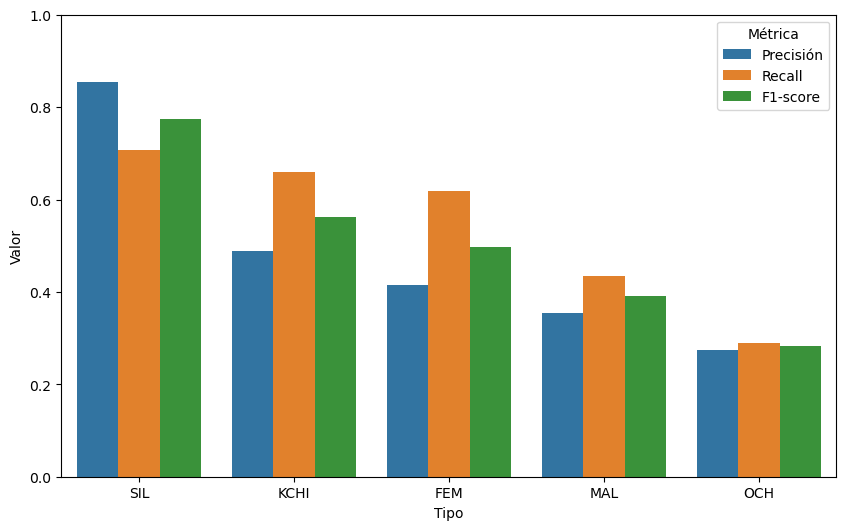

In [67]:
def plot_metrica(df_metrics, metrica, palette, filename):
    plt.figure(figsize=(8, 6))
    sns.barplot(
        x="Tipo",
        y=metrica,
        data=df_metrics,
        palette=palette
    )
    plt.title(f"{metrica} por Tipo")
    plt.ylim(0, 1)
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


def plot_metricas_combinadas(df_metrics, filename):
    df_melted = pd.melt(
        df_metrics,
        id_vars=["Tipo"],
        value_vars=["Precisión", "Recall", "F1-score"],
        var_name="Métrica",
        value_name="Valor"
    )

    plt.figure(figsize=(10, 6))
    sns.barplot(
        x="Tipo",
        y="Valor",
        hue="Métrica",
        data=df_melted
    )
    plt.ylim(0, 1)
    plt.legend(title="Métrica")
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


plot_metrica(df_metrics, "Precisión", "Blues_d",
             "outputs/final_concats/precision_sin_ELE.png")

plot_metrica(df_metrics, "Recall", "Greens_d",
             "outputs/final_concats/recall_sin_ELE.png")

plot_metrica(df_metrics, "F1-score", "Reds_d",
             "outputs/final_concats/f1_sin_ELE.png")

df_metrics = df_metrics.sort_values("F1-score", ascending=False)

plot_metricas_combinadas(
    df_metrics,
    "outputs/final_concats/metricas_combinadas_sin_ELE.png"
)


In [68]:
def plot_metrica(df_metrics, metrica, palette, filename):
    plt.figure(figsize=(8, 6))
    
    ax = sns.barplot(
        x="Tipo",
        y=metrica,
        data=df_metrics,
        palette=palette
    )

    plt.title(f"{metrica} por Tipo")
    plt.ylim(0, 1)

    # 👉 Forma robusta con bar_label
    for container in ax.containers:
        labels = [
            f"{v:.0f}%" if not pd.isna(v) else ""
            for v in container.datavalues
        ]
        ax.bar_label(container, labels=labels, padding=3, fontsize=10)

    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

In [69]:
df_metrics.columns = df_metrics.columns.str.strip()

In [70]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

def plot_metrica(df_metrics, metrica, color, filename):
    df_plot = df_metrics.copy()

    x = np.arange(len(df_plot))
    y = df_plot[metrica].astype(float).values
    labels = df_plot["Tipo"].astype(str).values

    plt.figure(figsize=(8, 6))
    bars = plt.bar(x, y, color=color)

    plt.title(f"{metrica} por Tipo")
    plt.xticks(x, labels)
    plt.ylabel(metrica)

    # dejar margen arriba para que entren los textos
    ymax = np.nanmax(y) if len(y) else 1
    plt.ylim(0, min(1.08, ymax + 0.12))

    for bar, val in zip(bars, y):
        if pd.notna(val):
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.015,
                f"{val:.0%}",
                ha="center",
                va="bottom",
                fontsize=10
            )

    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

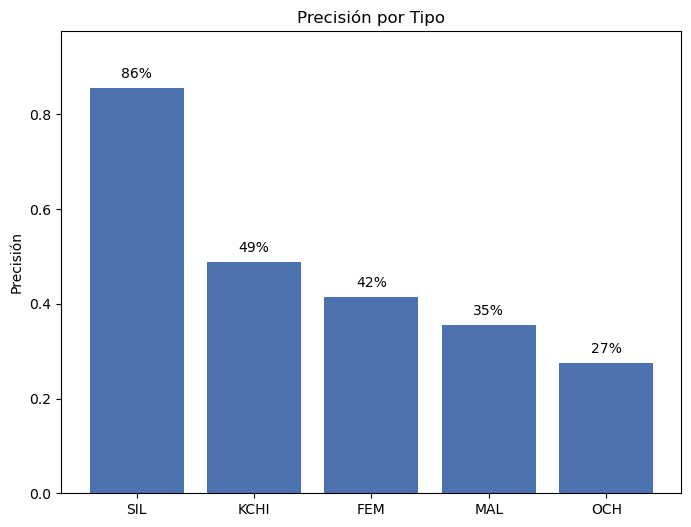

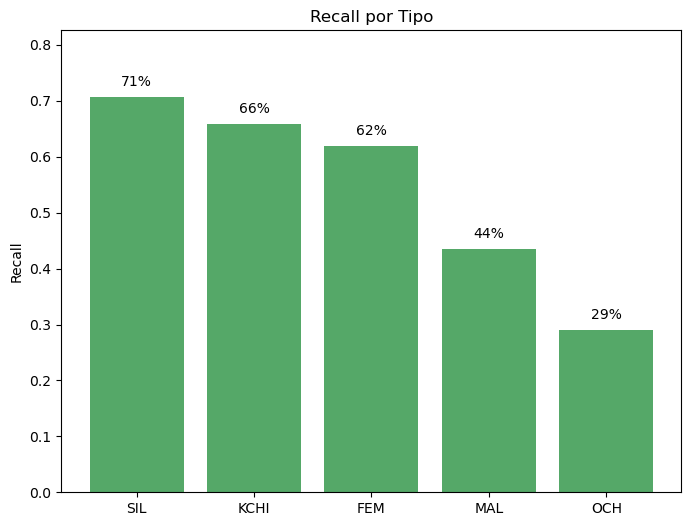

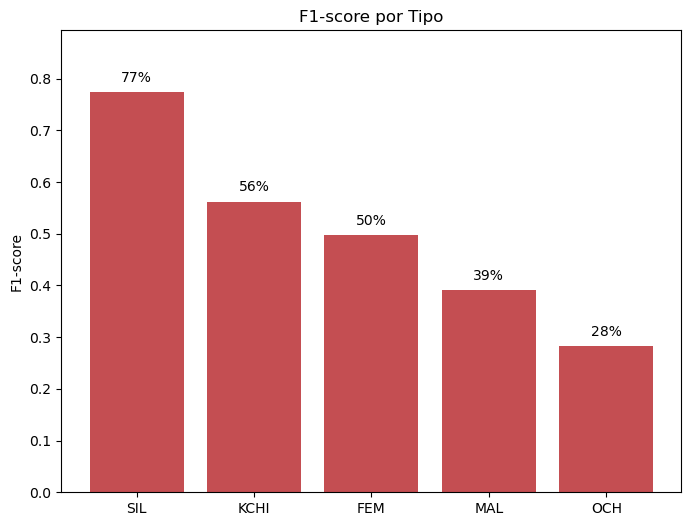

In [71]:
plot_metrica(
    df_metrics,
    "Precisión",
    "#4C72B0",
    "outputs/final_concats/precision_sin_ELE.png"
)

plot_metrica(
    df_metrics,
    "Recall",
    "#55A868",
    "outputs/final_concats/recall_sin_ELE.png"
)

plot_metrica(
    df_metrics,
    "F1-score",
    "#C44E52",
    "outputs/final_concats/f1_sin_ELE.png"
)

# Parte 10. Ranking por chico

In [72]:
from pathlib import Path
import pandas as pd

# =========================
# 1) CONFIGURACIÓN
# =========================
base_dir = Path(r"outputs\por_chico")
archivo_salida = Path(r"outputs\df_metrics_todos_los_chicos.csv")

# Si querés rankear solo ciertas clases, dejalas acá.
# Por ejemplo: ["FEM", "MAL", "KCHI"]
tipos_para_ranking = ["FEM", "MAL", "KCHI", "OCH"]

# =========================
# 2) RECORRER CARPETAS Y UNIR CSVs
# =========================
dfs = []

# Busca cualquier csv dentro de una subcarpeta llamada "csv"
for csv_file in base_dir.glob("*\\csv\\*.csv"):
    try:
        df = pd.read_csv(csv_file)

        # Nombre de la carpeta del chico, ej: alma-a1-nsb
        nombre_chico = csv_file.parent.parent.name

        # Nombre del archivo
        nombre_archivo = csv_file.name

        # Agregamos metadatos
        df["name"] = nombre_chico
        df["archivo_origen"] = nombre_archivo
        df["path"] = str(csv_file)

        # Opcional: separar info del nombre si sigue patrón tipo alma-a1-nsb
        partes = nombre_chico.split("-")
        if len(partes) >= 3:
            df["nombre_base"] = "-".join(partes[:-2])   # ej: alma
            df["corpus"] = partes[-2]                  # ej: a1
            df["ns_code"] = partes[-1]                 # ej: nsb
        else:
            df["nombre_base"] = nombre_chico
            df["corpus"] = None
            df["ns_code"] = None

        dfs.append(df)

    except Exception as e:
        print(f"Error leyendo {csv_file}: {e}")

if not dfs:
    raise ValueError("No se encontraron CSVs para unir.")

df_metrics_all = pd.concat(dfs, ignore_index=True)

# Guardar consolidado
archivo_salida.parent.mkdir(parents=True, exist_ok=True)
df_metrics_all.to_csv(archivo_salida, index=False, encoding="utf-8-sig")

print(f"CSV consolidado guardado en: {archivo_salida}")
print(f"Filas totales: {len(df_metrics_all)}")
print(f"Columnas: {df_metrics_all.columns.tolist()}")

# =========================
# 3) CARGAR CONSOLIDADO
# =========================
df = pd.read_csv(archivo_salida)

# Asegurar que F1-score sea numérico
df["F1-score"] = pd.to_numeric(df["F1-score"], errors="coerce")

# =========================
# 4) RANKING POR PROMEDIO DE F1
# =========================
# Ranking usando solo los tipos de interés
df_rank = df[df["Tipo"].isin(tipos_para_ranking)].copy()

ranking = (
    df_rank
    .groupby("name", as_index=False)
    .agg(
        f1_promedio=("F1-score", "mean"),
        n_filas=("F1-score", "size"),
        n_tipos=("Tipo", "nunique"),
        corpus=("corpus", "first"),
        ns_code=("ns_code", "first"),
    )
    .sort_values("f1_promedio", ascending=False)
    .reset_index(drop=True)
)

ranking["ranking"] = ranking.index + 1

# Reordenar columnas
ranking = ranking[
    ["ranking", "name", "corpus", "ns_code", "f1_promedio", "n_filas", "n_tipos"]
]

print("\n===== RANKING POR F1 PROMEDIO =====")
print(ranking)

# Guardar ranking
ranking_path = Path(r"outputs\ranking_f1_promedio.csv")
ranking.to_csv(ranking_path, index=False, encoding="utf-8-sig")
print(f"\nRanking guardado en: {ranking_path}")


CSV consolidado guardado en: outputs\df_metrics_todos_los_chicos.csv
Filas totales: 5088218
Columnas: ['Tipo', 'Precisión', 'Recall', 'F1-score', 'Support', 'name', 'archivo_origen', 'path', 'nombre_base', 'corpus', 'ns_code', 'Elan_KCHI', 'Elan_OCH', 'Elan_FEM', 'Elan_MAL', 'Elan_ELE', 'Diar_KCHI', 'Diar_OCH', 'Diar_FEM', 'Diar_MAL', 'Diar_SPEECH', 'Elan_SPEECH', 'Elan_SIL', 'Diar_SIL']


C:\Users\pablo\AppData\Local\Temp\ipykernel_4764\707792606.py:67: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(archivo_salida)



===== RANKING POR F1 PROMEDIO =====
    ranking               name corpus ns_code  f1_promedio  n_filas  n_tipos
0         1        alma-a1-nsb     a1     nsb     0.567843        4        4
1         2       verag-a2-nsm     a2     nsm     0.544746        4        4
2         3  franciscop-a2-nsm     a2     nsm     0.513893        4        4
3         4     amparol-a1-nsb     a1     nsb     0.502191        4        4
4         5      dantep-a1-nsm     a1     nsm     0.492102        4        4
5         6      dianag-a1-nsb     a1     nsb     0.475131        4        4
6         7   lisandroh-a2-nsm     a2     nsm     0.469679        4        4
7         8      lucior-a2-nsm     a2     nsm     0.466533        4        4
8         9   angelinap-a1-nsm     a1     nsm     0.464117        4        4
9        10    julietap-a1-nsm     a1     nsm     0.460615        4        4
10       11       gaell-a2-nsb     a2     nsb     0.459103        4        4
11       12     manuelc-a2-nsm     a2  

In [73]:
import pandas as pd

tipos_para_ranking = ["FEM", "MAL", "KCHI", "OCH"]

df = pd.read_csv(r"outputs\df_metrics_todos_los_chicos.csv")

# Asegurar numérico
df["F1-score"] = pd.to_numeric(df["F1-score"], errors="coerce")

# Filtrar tipos
df_rank = df[df["Tipo"].isin(tipos_para_ranking)].copy()

# =========================
# 1) Promedio por chico y tipo
# =========================
df_por_tipo = (
    df_rank
    .groupby(["name", "Tipo"], as_index=False)
    .agg(f1_promedio=("F1-score", "mean"))
)

# =========================
# 2) Pivotear → columnas por label
# =========================
df_pivot = df_por_tipo.pivot(
    index="name",
    columns="Tipo",
    values="f1_promedio"
).reset_index()

# Renombrar columnas
df_pivot = df_pivot.rename(columns={
    "FEM": "f1_FEM",
    "MAL": "f1_MAL",
    "KCHI": "f1_KCHI",
    "OCH": "f1_OCH"
})

# =========================
# 3) Promedio total (solo sobre los labels definidos)
# =========================
columnas_f1 = ["f1_FEM", "f1_MAL", "f1_KCHI", "f1_OCH"]

df_pivot["f1_promedio_total"] = df_pivot[columnas_f1].mean(axis=1)

# =========================
# 4) Agregar metadata (corpus / ns_code)
# =========================
meta = (
    df_rank
    .groupby("name", as_index=False)
    .agg(
        corpus=("corpus", "first"),
        ns_code=("ns_code", "first")
    )
)

df_final = df_pivot.merge(meta, on="name", how="left")

# =========================
# 5) Ranking
# =========================
df_final = df_final.sort_values("f1_promedio_total", ascending=False).reset_index(drop=True)
df_final["ranking"] = df_final.index + 1

# Orden final de columnas
df_final = df_final[
    ["ranking", "name", "corpus", "ns_code",
     "f1_promedio_total", "f1_FEM", "f1_MAL", "f1_KCHI", "f1_OCH"]
]


# Guardar
df_final.to_csv("outputs/ranking_f1_por_label.csv", index=False, encoding="utf-8-sig")
df_final

C:\Users\pablo\AppData\Local\Temp\ipykernel_4764\154983406.py:5: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"outputs\df_metrics_todos_los_chicos.csv")


,ranking,name,corpus,ns_code,f1_promedio_total,f1_FEM,f1_MAL,f1_KCHI,f1_OCH
0,1,alma-a1-nsb,a1,nsb,0.567843,0.624738,0.464171,0.642668,0.539797
1,2,verag-a2-nsm,a2,nsm,0.544746,0.819251,0.562983,0.796750,0.000000
2,3,franciscop-a2-nsm,a2,nsm,0.513893,0.744271,0.483493,0.827808,0.000000
3,4,amparol-a1-nsb,a1,nsb,0.502191,0.564282,0.426217,0.565517,0.452747
4,5,dantep-a1-nsm,a1,nsm,0.492102,0.730624,0.666058,0.571727,0.000000
5,6,dianag-a1-nsb,a1,nsb,0.475131,0.673355,0.272314,0.550755,0.404101
6,7,lisandroh-a2-nsm,a2,nsm,0.469679,0.614277,0.409740,0.495047,0.359653
7,8,lucior-a2-nsm,a2,nsm,0.466533,0.679651,0.376634,0.597606,0.212243
8,9,angelinap-a1-nsm,a1,nsm,0.464117,0.573500,0.445049,0.627462,0.210458
9,10,julietap-a1-nsm,a1,nsm,0.460615,0.685825,0.326197,0.830437,0.000000


In [74]:
import pandas as pd
import re

tipos_para_ranking = ["FEM", "MAL", "KCHI", "OCH"]

df = pd.read_csv(r"outputs\df_metrics_todos_los_chicos.csv")

# =========================
# 0) Limpieza
# =========================
df["F1-score"] = pd.to_numeric(df["F1-score"], errors="coerce")
df_rank = df[df["Tipo"].isin(tipos_para_ranking)].copy()

# Extraer nombre base del chico desde strings tipo:
# alma-a1-nsb -> alma
# verag-a2-nsm -> verag
def extraer_chico_base(x):
    x = str(x).strip().lower()
    m = re.match(r"^(.*?)-a\d+-ns[mb]$", x)
    if m:
        return m.group(1)
    return x

df_rank["chico"] = df_rank["name"].apply(extraer_chico_base)

# =========================
# 1) Promedio por chico y tipo
# =========================
df_por_tipo = (
    df_rank
    .groupby(["name", "chico", "Tipo"], as_index=False)
    .agg(f1_promedio=("F1-score", "mean"))
)

# =========================
# 2) Pivotear
# =========================
df_pivot = df_por_tipo.pivot(
    index=["name", "chico"],
    columns="Tipo",
    values="f1_promedio"
).reset_index()

df_pivot = df_pivot.rename(columns={
    "FEM": "f1_FEM",
    "MAL": "f1_MAL",
    "KCHI": "f1_KCHI",
    "OCH": "f1_OCH"
})

# Asegurar columnas aunque falte alguna
for col in ["f1_FEM", "f1_MAL", "f1_KCHI", "f1_OCH"]:
    if col not in df_pivot.columns:
        df_pivot[col] = pd.NA

# =========================
# 3) Promedio total
# =========================
columnas_f1 = ["f1_FEM", "f1_MAL", "f1_KCHI", "f1_OCH"]
df_pivot["f1_promedio_total"] = df_pivot[columnas_f1].mean(axis=1)

# =========================
# 4) ns_code
# =========================
meta = (
    df_rank
    .groupby(["name", "chico"], as_index=False)
    .agg(
        ns_code=("ns_code", "first")
    )
)

df_final = df_pivot.merge(meta, on=["name", "chico"], how="left")

# =========================
# 5) Map manual de corpus por chico
# =========================
map_corpus = {
    "alma": "raw_ROS",
    "amparol": "raw_ROS",
    "angelinap": "raw_ROS",
    "bautista": "segunda-vuelta/random",
    "bautistad": "segunda-vuelta/random",
    "biancak": "raw_ROS_HV",
    "brandona": "segunda-vuelta/highVol",
    "camilob": "segunda-vuelta/random",
    "camilop": "raw_ROS_HV",
    "dantec": "raw_ROS",
    "dantep": "raw_ROS_HV",
    "dianag": "raw_ROS_HV",
    "florl": "segunda-vuelta/random",
    "francescam": "raw_ROS_HV",
    "franciscop": "raw_ROS_HV",
    "gaell": "raw_ROS",
    "jeremiasc": "segunda-vuelta/highVol",
    "julietap": "raw_ROS_HV",
    "lisandroh": "raw_ROS",
    "lucasyoelp": "raw_ROS_HV",
    "lucior": "raw_ROS",
    "manuelc": "raw_ROS",
    "readme": "raw_ROS",   # si readme está duplicado, ver nota abajo
    "ummaq": "raw_ROS",
    "valentina": "segunda-vuelta/highVol",
    "valentinos": "raw_ROS",
    "verag": "raw_ROS_HV",
  
}

df_final["corpus"] = df_final["chico"].map(map_corpus)

# =========================
# 6) Ranking
# =========================
df_final = df_final.sort_values("f1_promedio_total", ascending=False).reset_index(drop=True)
df_final["ranking"] = df_final.index + 1

# =========================
# 7) Orden final
# =========================
df_final = df_final[
    [
        "ranking",
        "name",
        "chico",
        "corpus",
        "ns_code",
        "f1_promedio_total",
        "f1_FEM",
        "f1_MAL",
        "f1_KCHI",
        "f1_OCH"
    ]
]

# =========================
# 8) Revisar faltantes
# =========================
faltan_corpus = df_final[df_final["corpus"].isna()]
if not faltan_corpus.empty:
    print("\nNombres sin corpus asignado:")
    print(faltan_corpus[["name", "chico"]].drop_duplicates().sort_values("chico"))

# Guardar
df_final.to_csv("outputs/ranking_f1_por_label.csv", index=False, encoding="utf-8-sig")



C:\Users\pablo\AppData\Local\Temp\ipykernel_4764\2883757388.py:6: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"outputs\df_metrics_todos_los_chicos.csv")


In [75]:
df_final

,ranking,name,chico,corpus,ns_code,f1_promedio_total,f1_FEM,f1_MAL,f1_KCHI,f1_OCH
0,1,alma-a1-nsb,alma,raw_ROS,nsb,0.567843,0.624738,0.464171,0.642668,0.539797
1,2,verag-a2-nsm,verag,raw_ROS_HV,nsm,0.544746,0.819251,0.562983,0.796750,0.000000
2,3,franciscop-a2-nsm,franciscop,raw_ROS_HV,nsm,0.513893,0.744271,0.483493,0.827808,0.000000
3,4,amparol-a1-nsb,amparol,raw_ROS,nsb,0.502191,0.564282,0.426217,0.565517,0.452747
4,5,dantep-a1-nsm,dantep,raw_ROS_HV,nsm,0.492102,0.730624,0.666058,0.571727,0.000000
5,6,dianag-a1-nsb,dianag,raw_ROS_HV,nsb,0.475131,0.673355,0.272314,0.550755,0.404101
6,7,lisandroh-a2-nsm,lisandroh,raw_ROS,nsm,0.469679,0.614277,0.409740,0.495047,0.359653
7,8,lucior-a2-nsm,lucior,raw_ROS,nsm,0.466533,0.679651,0.376634,0.597606,0.212243
8,9,angelinap-a1-nsm,angelinap,raw_ROS,nsm,0.464117,0.573500,0.445049,0.627462,0.210458
9,10,julietap-a1-nsm,julietap,raw_ROS_HV,nsm,0.460615,0.685825,0.326197,0.830437,0.000000
